In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir('/Users/stacyli/sudmant/spermSV/analysis/hg38/alu/notebooks')
import gff_utils

sns.set_style('white')

### common variables to be accessed in other rules/helper functions ###
sample_table = pd.read_table('../../../../config/snakemake/samples.tsv', index_col=False, dtype=str)
specimens = [x for x in sample_table['specimen'].unique() if x != 'HG002']
specimens_by_group = sample_table.groupby('group')['specimen'].unique().apply(list).to_dict()

/Users/stacyli/sudmant/spermSV/analysis/hg38/alu/notebooks/gff_utils.py:27: SyntaxWarning: invalid escape sequence '\:'
  aGFF['motif'] = aGFF['attribute'].str.extract('(?<=\:)(.*)(?=\")')


# hg38 analysis

In [4]:
# chrom_morph dictionary

chrom_morph = {'chr1': 'metacentric',
              'chr2': 'submetacentric',
              'chr3': 'metacentric',
              'chr4': 'submetacentric',
              'chr5': 'submetacentric',
              'chr6': 'submetacentric',
              'chr7': 'submetacentric',
              'chr8': 'submetacentric',
              'chr10': 'submetacentric',
              'chr11': 'submetacentric',
              'chr12': 'submetacentric',
              'chr13': 'acrocentric',
              'chr14': 'acrocentric',
              'chr15': 'acrocentric',
              'chr16': 'metacentric',
              'chr17': 'submetacentric',
              'chr18': 'submetacentric',
              'chr19': 'metacentric',
              'chr20': 'metacentric',
              'chr21': 'acrocentric',
              'chr22': 'acrocentric',
              'chrX': 'submetacentric',
              'chrY': 'acrocentric'}

## AluY* subfamily

In [5]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in specimens:
    sample_aluY = gff_utils.AnnotatedGFF().create(f'../../../../output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', 
                                                  f'../repeatmasker/{sample}.alt.fa.out.gff', 
                                                  motif = 'AluY')
    # sample_aluY.table.to_gff3(f'../files/{sample}_aluY_hg38.gff', return_df = False)
    sample_aluY.table['origin'] = sample
    samples_annotated[sample] = sample_aluY

AluY_samples = pd.concat([x.table for x in samples_annotated.values()])

# keep a copy of this "raw" table for pre/post filtering plot
unfilt_AluY_samples = AluY_samples.copy()

# drop variants on random* ctgs in main table
AluY_samples = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')]
# annotate chromosome type
AluY_samples['chrom_morph'] =  AluY_samples['#CHROM'].map(chrom_morph)
# limit to acceptable counts of ref/support reads
AluY_samples = AluY_samples.query(f"ref_reads <= 80 & alt_reads <= 10")
# finally, reset index
AluY_samples.reset_index(drop = True, inplace = True)

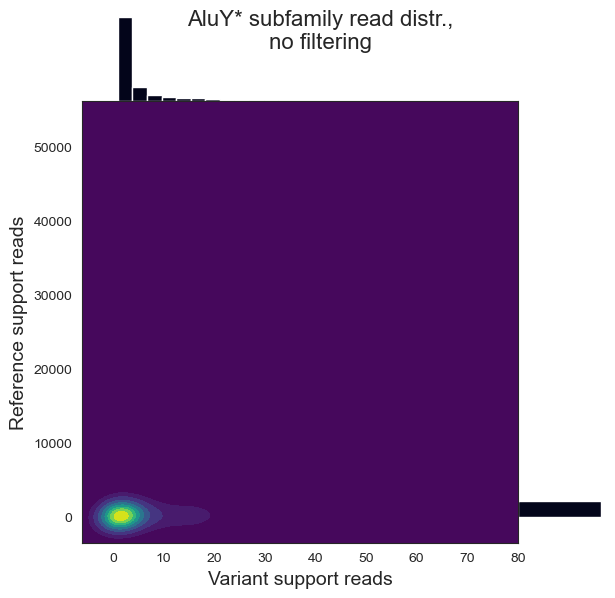

In [11]:
# unfilt read support heatmap
g = sns.JointGrid(data=unfilt_AluY_samples, x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("AluY* subfamily read distr.,\nno filtering", size = 16)
plt.savefig("../figures/read_heatmap.unfilt.png")

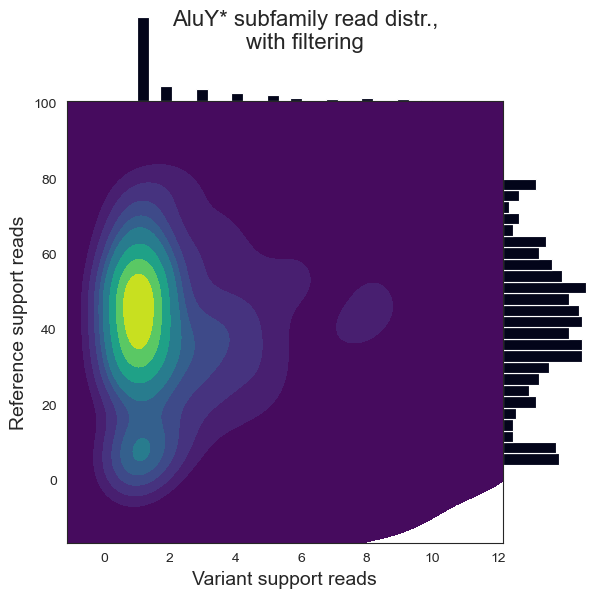

In [10]:
# post-filt read support heatmap
g = sns.JointGrid(data=AluY_samples, x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("AluY* subfamily read distr.,\nwith filtering", size = 16)
plt.savefig("../figures/read_heatmap.filt.png")

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_18077/3538839841.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.histplot(ax = axes[1], data = unfilt_AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge",


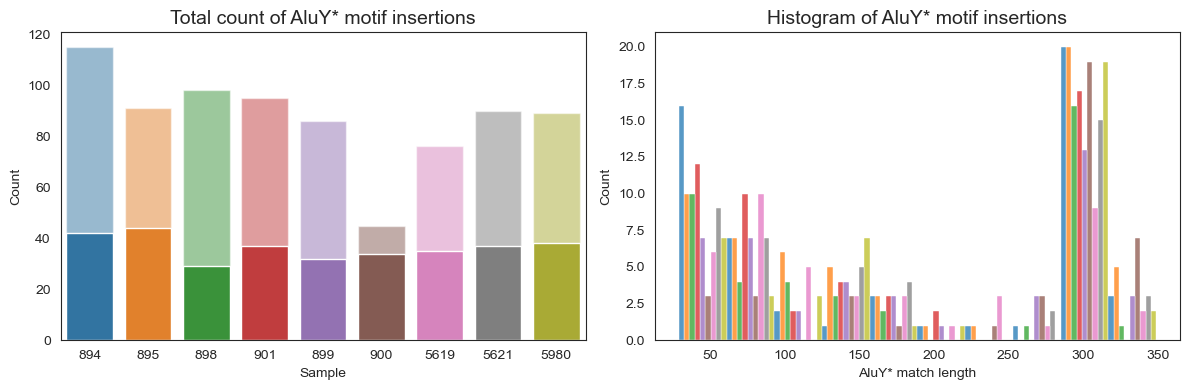

In [12]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = unfilt_AluY_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = unfilt_AluY_samples[~unfilt_AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of AluY* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = unfilt_AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge",
             legend = None)
axes[1].set_title("Histogram of AluY* motif insertions", size = 14)
axes[1].set_xlabel("AluY* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../figures/summary.png")

In [9]:
# export a list of RNAMES for bam filtering
# then save to base csv for various other markup

for sample in specimens:
    samples_annotated[sample].export_rnames(f'../files/{sample}_aluY.txt')
    samples_annotated[sample].filter_reads(80, 10).to_csv(f'../files/{sample}_aluY.base.csv')

Saving .txt file to ../files/894_aluY.txt ...
Saving .txt file to ../files/895_aluY.txt ...
Saving .txt file to ../files/898_aluY.txt ...
Saving .txt file to ../files/901_aluY.txt ...
Saving .txt file to ../files/899_aluY.txt ...
Saving .txt file to ../files/900_aluY.txt ...
Saving .txt file to ../files/5619_aluY.txt ...
Saving .txt file to ../files/5621_aluY.txt ...
Saving .txt file to ../files/5980_aluY.txt ...


### Snakemake-d steps

`rules/alu.smk` should be written to contain rules specific to this analysis.

### After genome browser annotation

In [63]:
# read in super duper annotated files, create a combined table & save for later use

# samples_annotated = dict()
# for sample in specimens:
#     samples_annotated[sample]= pd.read_csv(f'../files/{sample}_aluY_hg38.csv', index_col = 0, encoding = 'latin-1')

# AluY_samples = pd.concat(samples_annotated.values()).reset_index(drop = True)

AluY_samples = pd.read_csv('../files/all_aluY_hg38.csv', index_col = 0)

In [10]:
AluY_samples.groupby('protein coding?').size()

protein coding?
no     22
yes    50
dtype: int64

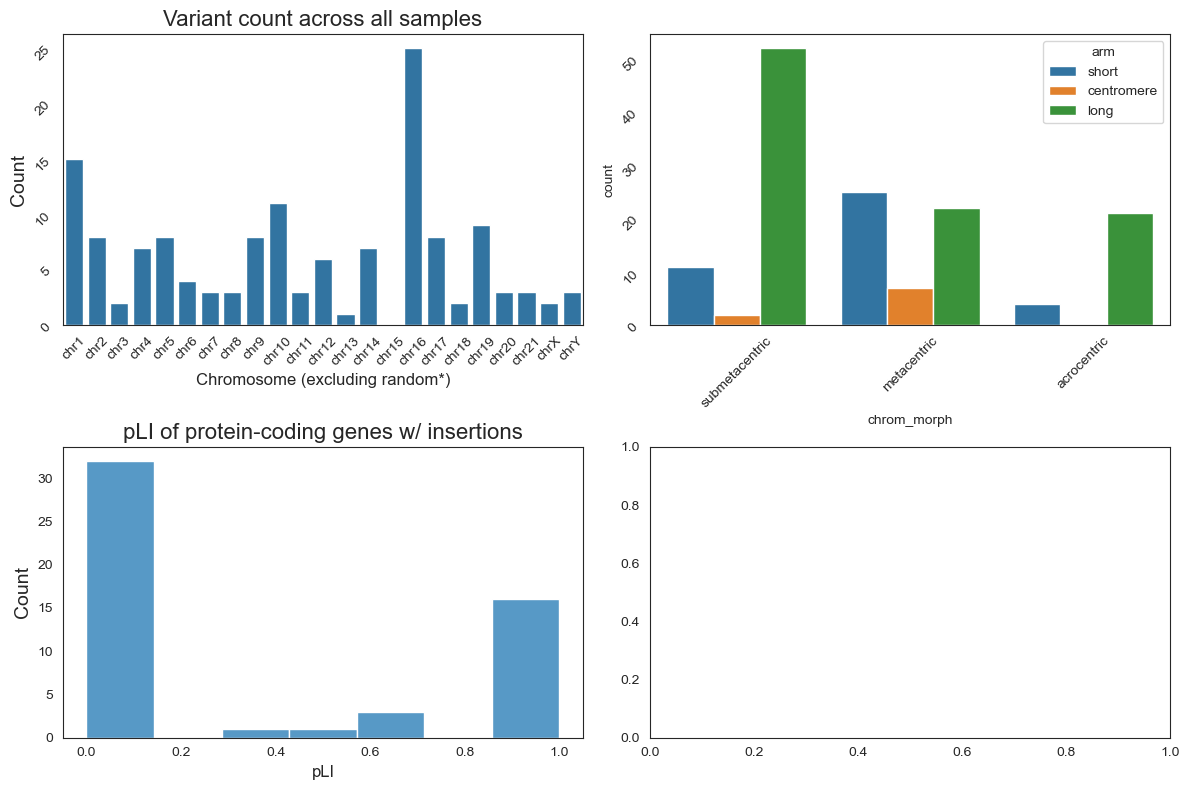

In [64]:
# note that these figures exclude variants on random* ctgs

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = AluY_samples, x = '#CHROM',
            order = ['chr{n}'.format(n = chrom) for chrom in list(np.arange(1,22)) + ['X', 'Y']])
axes[0].tick_params(labelrotation = 45)
axes[0].set_title("Variant count across all samples", size = 16)
axes[0].set_ylabel("Count", size = 14)
axes[0].set_xlabel("Chromosome (excluding random*)", size = 12)

sns.countplot(ax = axes[1], data = AluY_samples, x = 'chrom_morph', hue = 'arm',
            order = ['submetacentric', 'metacentric', 'acrocentric'],
            hue_order = ['short', 'centromere', 'long'])
axes[1].tick_params(labelrotation = 45)

sns.histplot(ax = axes[2], data = AluY_samples, x = 'PLI (gnomAD)')
axes[2].set_title("pLI of protein-coding genes w/ insertions", size = 16)
axes[2].set_ylabel("Count", size = 14)
axes[2].set_xlabel("pLI", size = 12)

plt.tight_layout()

<Axes: xlabel='#CHROM'>

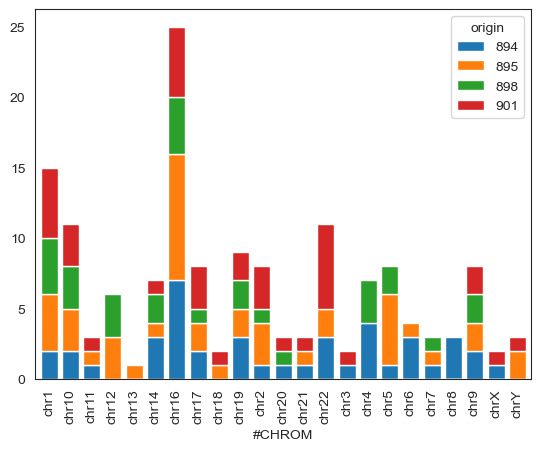

In [110]:
# stacked barplot version
# https://stackoverflow.com/questions/50319614/count-plot-with-stacked-bars-per-hue

AluY_samples.groupby(['#CHROM', 'origin']).size().reset_index().pivot(columns = 'origin', index = '#CHROM', values = 0).plot(kind = 'bar', stacked = True, width = 0.8)

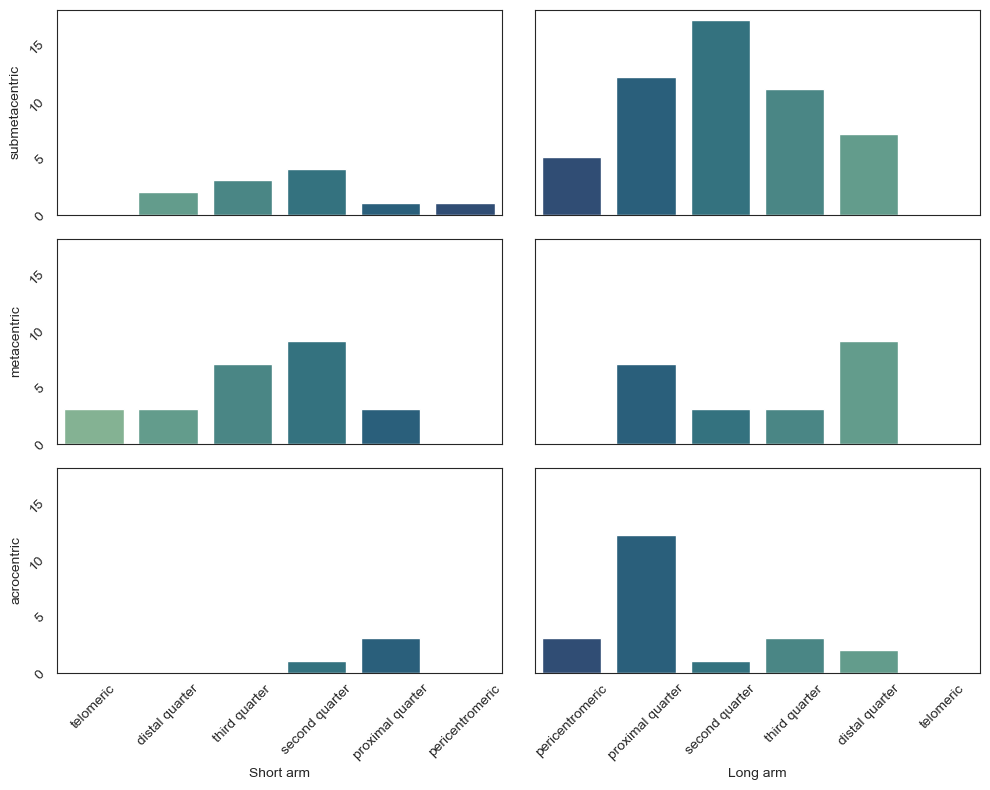

In [8]:
# plot version 1
# note that these figures exclude variants on random* ctgs, as filtered above

location_palette = dict(zip(['telomeric', 'distal quarter', 'third quarter', 'second quarter', 'proximal quarter', 'pericentromeric'], sns.color_palette('crest', 6)))

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (10, 8), sharey = True)
# axes = axes.flatten()

# short arm: telomeric to centromeric, excludes centromeres
for arm, morph, row in zip(['short']*3, ['submetacentric', 'metacentric', 'acrocentric'], [0,1,2]):
    sns.countplot(ax = axes[row, 0], data = AluY_samples.query(f"chrom_morph == '{morph}' & arm == '{arm}' & location != 'centromeric'"), 
                  x = 'location', hue = 'location',
                  order = ['telomeric', 'distal quarter', 'third quarter', 'second quarter', 'proximal quarter', 'pericentromeric'],
                  palette = location_palette)
    axes[row, 0].tick_params(labelrotation = 45)
    axes[row, 0].set_ylabel(f'{morph}')
    if row != 2:
        axes[row,0].set_xlabel('')
        axes[row,0].get_xaxis().set_ticks([])

# long arm: centromeric to telomeric, excludes centromeres
for arm, morph, row in zip(['long']*3, ['submetacentric', 'metacentric', 'acrocentric'], [0,1,2]):
    sns.countplot(ax = axes[row, 1], data = AluY_samples.query(f"chrom_morph == '{morph}' & arm == '{arm}' & location != 'centromeric'"), 
                  x = 'location', hue = 'location',
                  order = ['pericentromeric', 'proximal quarter', 'second quarter', 'third quarter', 'distal quarter', 'telomeric'],
                  palette = location_palette)
    axes[row, 1].tick_params(labelrotation = 45)
    if row != 2:
        axes[row,1].set_xlabel('')
        axes[row,1].get_xaxis().set_ticks([])

axes[2, 0].set_xlabel(f"Short arm")
axes[2, 1].set_xlabel(f"Long arm")

plt.tight_layout()

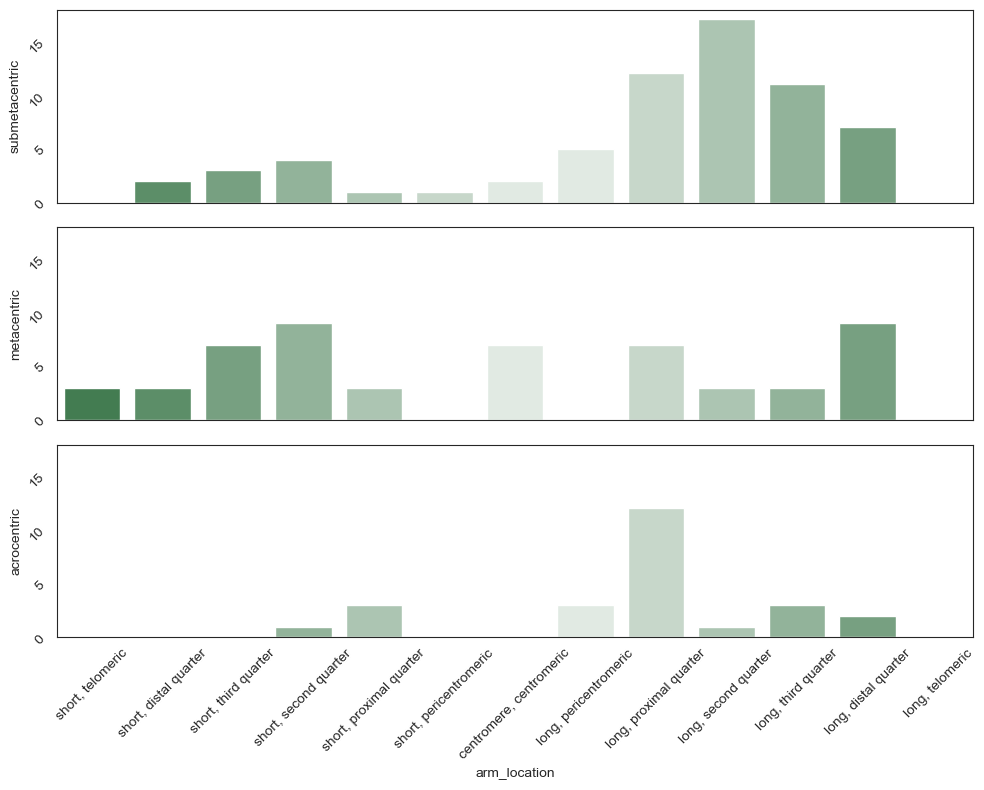

In [79]:
# plot version 2
# note that these figures exclude variants on random* ctgs, as filtered above

location_palette = dict(zip(['short, telomeric', 'short, distal quarter', 'short, third quarter', 'short, second quarter', 'short, proximal quarter', 'short, pericentromeric', 'centromere, centromeric', 'long, pericentromeric', 'long, proximal quarter', 'long, second quarter', 'long, third quarter', 'long, distal quarter', 'long, telomeric'], 
                    sns.diverging_palette(134, 134, n = 14, center='light')))

plot_specific = AluY_samples.copy()
plot_specific['arm_location'] = plot_specific[['arm', 'location']].apply(lambda x: ', '.join(x), axis = 1)
plot_specific.drop(columns = ['arm', 'location'], inplace = True)

fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (10, 8), sharey = True, sharex = True)
axes = axes.flatten()

for morph, ax in zip(['submetacentric', 'metacentric', 'acrocentric'], axes):
    sns.countplot(ax = ax, data = plot_specific.query(f"chrom_morph == '{morph}'"), 
                  x = 'arm_location', hue = 'arm_location',
                  order = ['short, telomeric', 'short, distal quarter', 'short, third quarter', 'short, second quarter', 'short, proximal quarter', 'short, pericentromeric', 'centromere, centromeric', 'long, pericentromeric', 'long, proximal quarter', 'long, second quarter', 'long, third quarter', 'long, distal quarter', 'long, telomeric'],
                  palette = location_palette)
    ax.tick_params(labelrotation = 45)
    ax.set_ylabel(f'{morph}')
    # if row != 2:
    #     axes[row,0].set_xlabel('')
    #     axes[row,0].get_xaxis().set_ticks([])

plt.tight_layout()

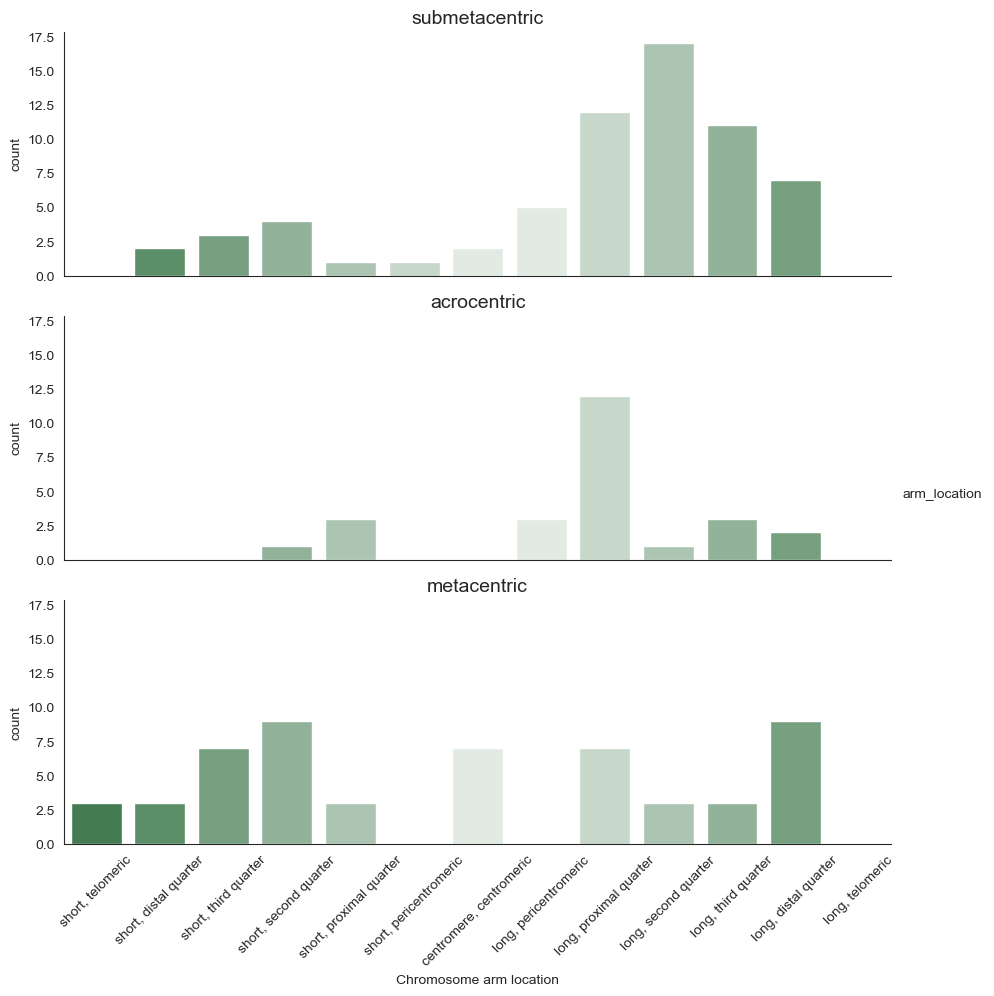

In [81]:
# plot version 3

location_palette = dict(zip(['short, telomeric', 'short, distal quarter', 'short, third quarter', 'short, second quarter', 'short, proximal quarter', 'short, pericentromeric', 'centromere, centromeric', 'long, pericentromeric', 'long, proximal quarter', 'long, second quarter', 'long, third quarter', 'long, distal quarter', 'long, telomeric'], 
                    sns.diverging_palette(134, 134, n = 14, center='light')))

g = sns.catplot(data=plot_specific, x="arm_location", row="chrom_morph", kind="count", hue = "arm_location", 
            col_order = ['submetacentric', 'metacentric', 'acrocentric'],
            height = 3, aspect = 3,
            palette = location_palette,
            margin_titles = False,
            order = ['short, telomeric', 'short, distal quarter', 'short, third quarter', 'short, second quarter', 'short, proximal quarter', 'short, pericentromeric', 'centromere, centromeric', 'long, pericentromeric', 'long, proximal quarter', 'long, second quarter', 'long, third quarter', 'long, distal quarter', 'long, telomeric'])

g.set_titles(row_template = "{row_name}", size = 14)
g.set_xlabels("Chromosome arm location")
g.tick_params(axis = 'x', labelrotation = 45)

## SVA family (deprecated)

In [27]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in specimens:
    sample_SVA = gff_utils.annotate_gff(f'../../../../output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'../repeatmasker/{sample}.alt.fa.out.gff', motif = 'SVA')
    sample_SVA['origin'] = sample
    # sample_gff3 = gff_utils.to_gff3(f'../files/{sample}_SVA_hg38.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_SVA

SVA_samples = pd.concat(list(samples_annotated.values()))

Text(0.5, 0.98, 'SVA* family\nread distribution')

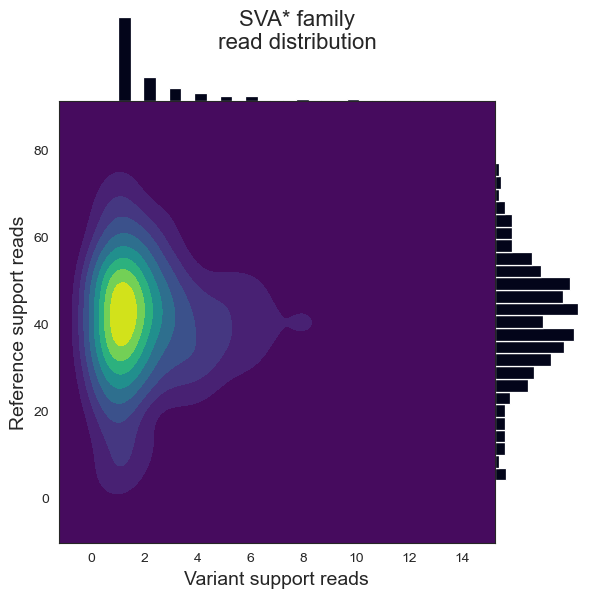

In [28]:
# use viz limits to determine the cutoff vals for filtering

g = sns.JointGrid(data=SVA_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("SVA* family\nread distribution", size = 16)

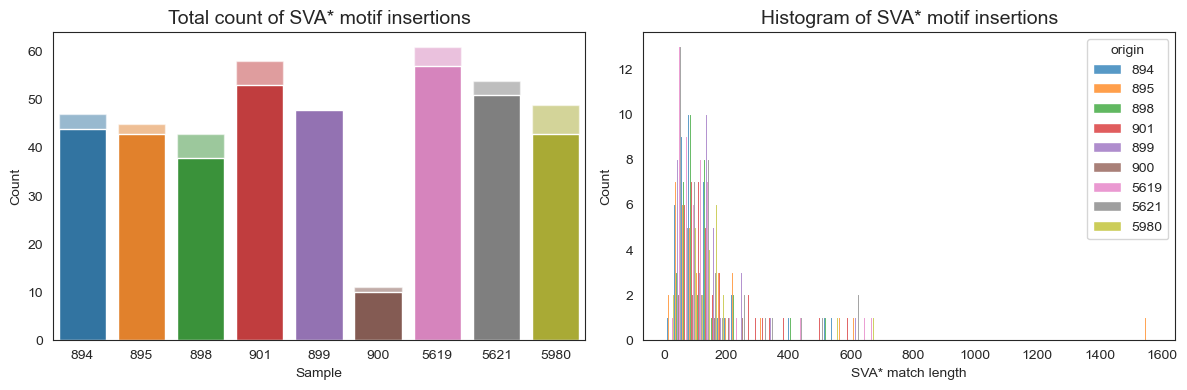

In [29]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = SVA_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of SVA* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of SVA* motif insertions", size = 14)
axes[1].set_xlabel("SVA* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()

## L1 family (deprecated)

In [30]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in specimens:
    sample_L1 = gff_utils.annotate_gff(f'../../../../output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'../repeatmasker/{sample}.alt.fa.out.gff', motif = 'L1')
    sample_L1['origin'] = sample
    # sample_gff3 = gff_utils.to_gff3(f'../files/{sample}_L1_hg38.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_L1

L1_samples = pd.concat(list(samples_annotated.values()))

Text(0.5, 0.98, 'L1* family\nread distribution')

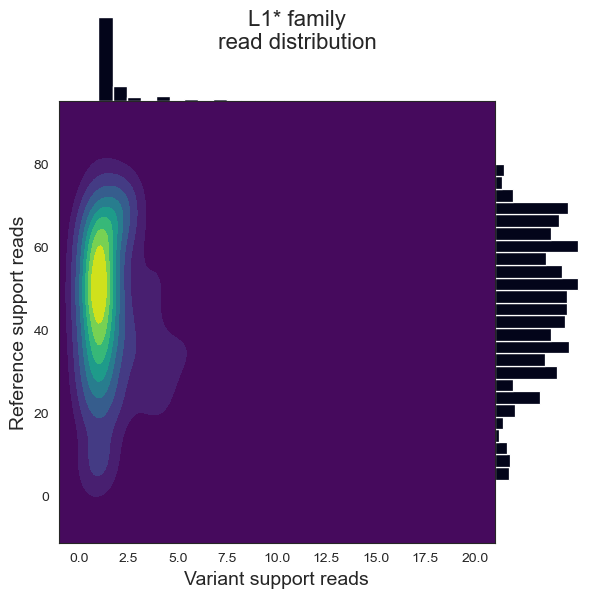

In [31]:
g = sns.JointGrid(data=L1_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("L1* family\nread distribution", size = 16)

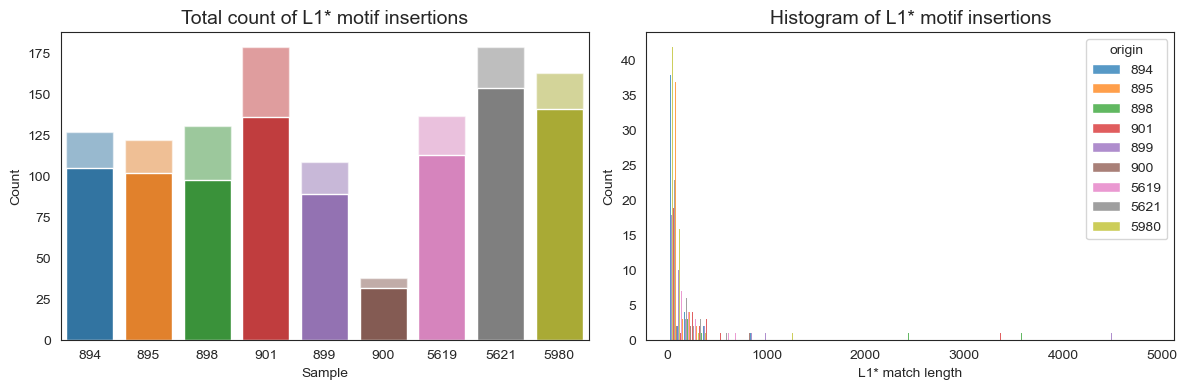

In [32]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = L1_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of L1* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of L1* motif insertions", size = 14)
axes[1].set_xlabel("L1* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()